In [1]:
import os
import time
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score,precision_score, recall_score,f1_score,roc_auc_score,average_precision_score, classification_report,confusion_matrix,ConfusionMatrixDisplay)

# Imbalanced Learning
from imblearn.over_sampling import RandomOverSampler

In [2]:
# Load Dataset
df = pd.read_csv(r'D:\Data_D\TMU\MRP\1.0.Dataset\Final_Crime_Dataset.csv')
print(df.shape)
print(df.columns.tolist())

(7970658, 28)
['Primary Type', 'Description', 'Location Description', 'Domestic', 'Beat', 'District', 'community_area', 'FBI Code', 'year', 'Latitude', 'Longitude', 'month', 'day_of_week', 'hour', 'per_capita_income', 'unemployment_rate', 'no_highschool_pct', 'date', 'TMAX', 'TMIN', 'PRCP', 'AWND', 'temp_avg', 'bus', 'rail_boardings', 'total_rides', 'day', 'Arrest']


In [3]:
print(df["Arrest"].value_counts())
print(round(df["Arrest"].value_counts(normalize=True) * 100, 2))

Arrest
0    5913853
1    2056805
Name: count, dtype: int64
Arrest
0    74.2
1    25.8
Name: proportion, dtype: float64


In [4]:
# Split Features and Target
X = df.drop("Arrest", axis=1)
y = df["Arrest"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (7970658, 27)
Target Shape  : (7970658,)


In [5]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)
print(f"X_train Shape : {X_train.shape}")
print(f"X_test Shape  : {X_test.shape}")

print(f"y_train Shape : {y_train.shape}")
print(f"y_test Shape  : {y_test.shape}")

X_train Shape : (6376526, 27)
X_test Shape  : (1594132, 27)
y_train Shape : (6376526,)
y_test Shape  : (1594132,)


In [6]:
# Random over Sampling
oversampler = RandomOverSampler(random_state=42)

X_train_over, y_train_over = oversampler.fit_resample(X_train,y_train)
print(y_train.value_counts())
print(y_train_over.value_counts())

print(f"\nX_train_over Shape : {X_train_over.shape}")
print(f"y_train_over Shape : {y_train_over.shape}")

Arrest
0    4731082
1    1645444
Name: count, dtype: int64
Arrest
0    4731082
1    4731082
Name: count, dtype: int64

X_train_over Shape : (9462164, 27)
y_train_over Shape : (9462164,)


In [7]:
# Label Encoding
categorical_columns = X_train_over.select_dtypes(include=["object"]).columns

label_encoders = {}
for column in categorical_columns:
    encoder = LabelEncoder()
    X_train_over[column] = encoder.fit_transform(X_train_over[column].astype(str))
    X_test[column] = encoder.transform(X_test[column].astype(str))
    label_encoders[column] = encoder

print(categorical_columns.tolist())

[]


In [8]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_over)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled Shape : {X_train_scaled.shape}")
print(f"X_test_scaled Shape  : {X_test_scaled.shape}")

X_train_scaled Shape : (9462164, 27)
X_test_scaled Shape  : (1594132, 27)


In [9]:
# Output Folders
MODEL_FOLDER = "2. Over_Sampling_Models"
RESULT_FOLDER = "2. Over_Sampling_Results"

os.makedirs(MODEL_FOLDER, exist_ok=True)
os.makedirs(RESULT_FOLDER, exist_ok=True)

In [10]:
joblib.dump(label_encoders, os.path.join(MODEL_FOLDER, "label_encoders.pkl"))
joblib.dump(scaler, os.path.join(MODEL_FOLDER, "standard_scaler.pkl"))

['2. Over_Sampling_Models\\standard_scaler.pkl']

In [11]:
# Create result List 
all_results = []

In [12]:
# Evaluation, Training, Predictions, Metrics, Classification Report, Confusion Matrix, Save Model 

def evaluate_model(
    model,
    model_name,
    X_train,
    y_train,
    X_test,
    y_test,
    model_folder=MODEL_FOLDER,
    result_folder=RESULT_FOLDER
):
    
    # Train Model
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    print(f"\nTraining Time : {training_time:.2f} seconds")

    # Prediction
    y_pred = model.predict(X_test)

    # Probability / Score Prediction
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]

    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)

    else:
        raise AttributeError(
            f"{model_name} does not support predict_proba() or decision_function()."
        )

   # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")
    print(f"PR AUC    : {pr_auc:.4f}")

   # Classification Report
    report = classification_report(y_test,y_pred,output_dict=True)
    print(classification_report(y_test, y_pred))
    report_df = pd.DataFrame(report).transpose()
    report_path = os.path.join(result_folder,f"{model_name}_Classification_Report.csv")
    report_df.to_csv(report_path)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm,index=["Actual_0","Actual_1"], columns=["Predicted_0","Predicted_1"])
    cm_path = os.path.join(result_folder,f"{model_name}_Confusion_Matrix.csv")
    cm_df.to_csv(cm_path)

    fig, ax = plt.subplots(figsize=(6,5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Arrest","Arrest"])
    disp.plot(cmap="Blues",ax=ax,colorbar=False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    figure_path = os.path.join(result_folder,f"{model_name}_Confusion_Matrix.png")
    plt.savefig(figure_path,dpi=300,bbox_inches="tight")
    plt.show()

    # Save Model
    model_path = os.path.join(model_folder,f"{model_name}.pkl")
    joblib.dump(model, model_path)
    
    # Store Results
    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc,
        "Training Time (s)": round(training_time, 2)
    }
    all_results.append(results)

    return results

# Logistic Regression


Training Time : 10.60 seconds
Accuracy  : 0.7478
Precision : 0.5091
Recall    : 0.6404
F1 Score  : 0.5672
ROC AUC   : 0.7547
PR AUC    : 0.5248
              precision    recall  f1-score   support

           0       0.86      0.79      0.82   1182771
           1       0.51      0.64      0.57    411361

    accuracy                           0.75   1594132
   macro avg       0.69      0.71      0.69   1594132
weighted avg       0.77      0.75      0.76   1594132



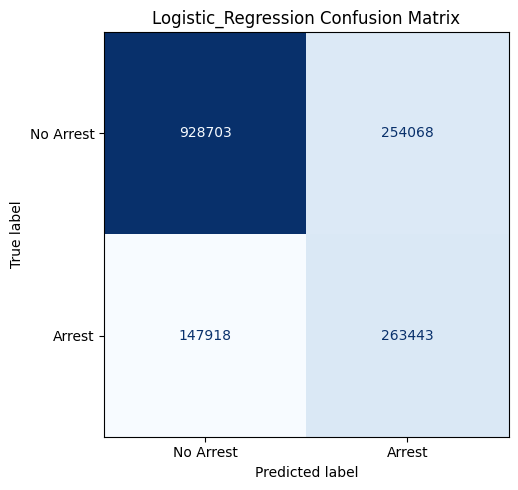

In [13]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)

lr_results = evaluate_model(
    model=lr_model,
    model_name="Logistic_Regression",
    X_train=X_train_scaled,
    y_train=y_train_over,
    X_test=X_test_scaled,
    y_test=y_test
)

# Decision Tree


Training Time : 429.38 seconds
Accuracy  : 0.8341
Precision : 0.6748
Recall    : 0.6892
F1 Score  : 0.6819
ROC AUC   : 0.7869
PR AUC    : 0.5454
              precision    recall  f1-score   support

           0       0.89      0.88      0.89   1182771
           1       0.67      0.69      0.68    411361

    accuracy                           0.83   1594132
   macro avg       0.78      0.79      0.78   1594132
weighted avg       0.84      0.83      0.83   1594132



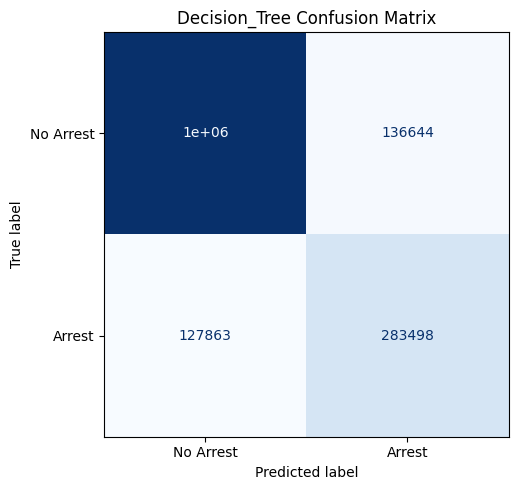

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_results = evaluate_model(
    model=dt_model,
    model_name="Decision_Tree",
    X_train=X_train_over,
    y_train=y_train_over,
    X_test=X_test,
    y_test=y_test
)

# Random Forest


Training Time : 631.86 seconds
Accuracy  : 0.8908
Precision : 0.8723
Recall    : 0.6760
F1 Score  : 0.7617
ROC AUC   : 0.9122
PR AUC    : 0.8545
              precision    recall  f1-score   support

           0       0.90      0.97      0.93   1182771
           1       0.87      0.68      0.76    411361

    accuracy                           0.89   1594132
   macro avg       0.88      0.82      0.85   1594132
weighted avg       0.89      0.89      0.89   1594132



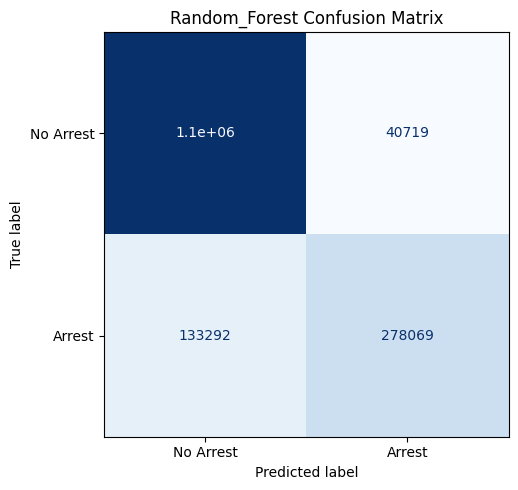

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

rf_results = evaluate_model(
    model=rf_model,
    model_name="Random_Forest",
    X_train=X_train_over,
    y_train=y_train_over,
    X_test=X_test,
    y_test=y_test
)

# Extra Trees


Training Time : 555.41 seconds
Accuracy  : 0.8890
Precision : 0.8965
Recall    : 0.6440
F1 Score  : 0.7496
ROC AUC   : 0.9044
PR AUC    : 0.8444
              precision    recall  f1-score   support

           0       0.89      0.97      0.93   1182771
           1       0.90      0.64      0.75    411361

    accuracy                           0.89   1594132
   macro avg       0.89      0.81      0.84   1594132
weighted avg       0.89      0.89      0.88   1594132



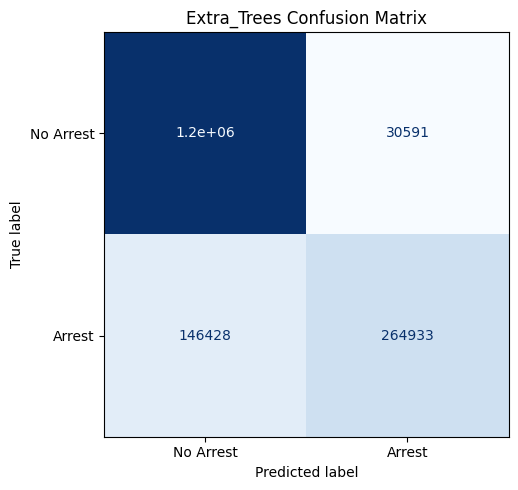

In [16]:

from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=False,
    n_jobs=-1,
    random_state=42
)

et_results = evaluate_model(
    model=et_model,
    model_name="Extra_Trees",
    X_train=X_train_over,
    y_train=y_train_over,
    X_test=X_test,
    y_test=y_test
)

# Gradient Boosting


Training Time : 4069.94 seconds
Accuracy  : 0.8627
Precision : 0.7429
Recall    : 0.7157
F1 Score  : 0.7291
ROC AUC   : 0.8986
PR AUC    : 0.8352
              precision    recall  f1-score   support

           0       0.90      0.91      0.91   1182771
           1       0.74      0.72      0.73    411361

    accuracy                           0.86   1594132
   macro avg       0.82      0.81      0.82   1594132
weighted avg       0.86      0.86      0.86   1594132



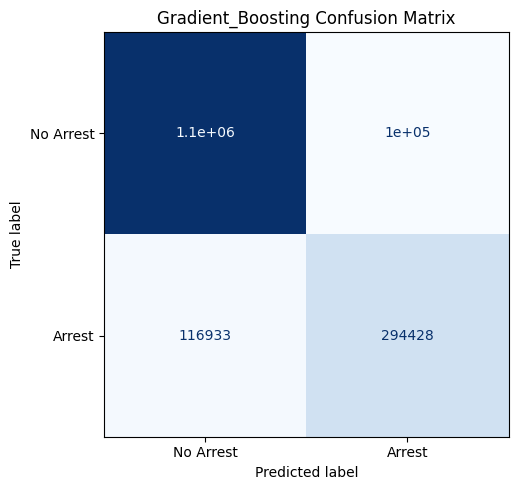

In [17]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    loss='log_loss',
    learning_rate=0.1,
    n_estimators=100,
    subsample=1.0,
    max_depth=3,
    random_state=42
)

gb_results = evaluate_model(
    model=gb_model,
    model_name="Gradient_Boosting",
    X_train=X_train_over,
    y_train=y_train_over,
    X_test=X_test,
    y_test=y_test
)

# AdaBoost


Training Time : 1584.49 seconds
Accuracy  : 0.8295
Precision : 0.6624
Recall    : 0.6919
F1 Score  : 0.6768
ROC AUC   : 0.8758
PR AUC    : 0.7973
              precision    recall  f1-score   support

           0       0.89      0.88      0.88   1182771
           1       0.66      0.69      0.68    411361

    accuracy                           0.83   1594132
   macro avg       0.78      0.78      0.78   1594132
weighted avg       0.83      0.83      0.83   1594132



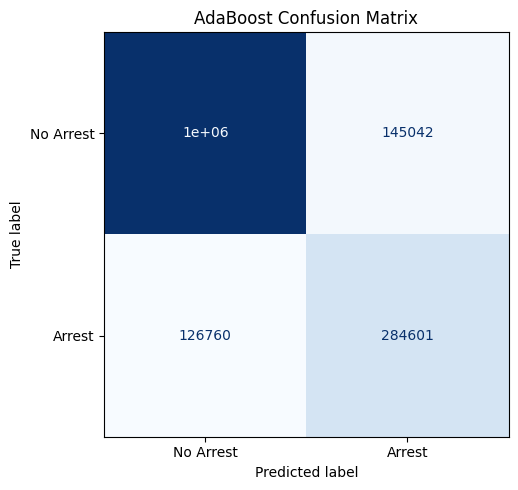

In [18]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada_results = evaluate_model(
    model=ada_model,
    model_name="AdaBoost",
    X_train=X_train_over,
    y_train=y_train_over,
    X_test=X_test,
    y_test=y_test
)

# XGBoost


Training Time : 25.44 seconds
Accuracy  : 0.8639
Precision : 0.7305
Recall    : 0.7489
F1 Score  : 0.7396
ROC AUC   : 0.9115
PR AUC    : 0.8530
              precision    recall  f1-score   support

           0       0.91      0.90      0.91   1182771
           1       0.73      0.75      0.74    411361

    accuracy                           0.86   1594132
   macro avg       0.82      0.83      0.82   1594132
weighted avg       0.87      0.86      0.86   1594132



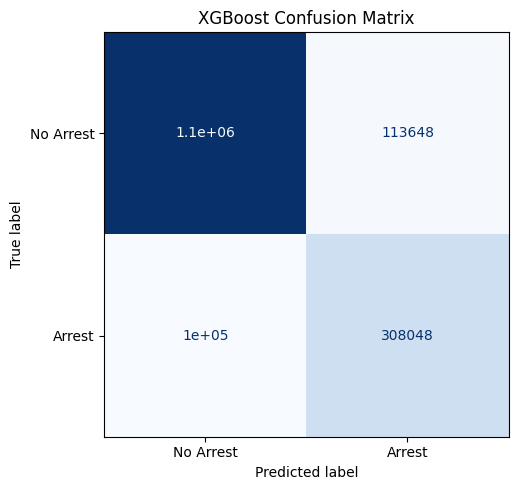

In [19]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_results = evaluate_model(
    model=xgb_model,
    model_name="XGBoost",
    X_train=X_train_over,
    y_train=y_train_over,
    X_test=X_test,
    y_test=y_test
)

# LightGBM

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4731082, number of negative: 4731082
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.149204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3495
[LightGBM] [Info] Number of data points in the train set: 9462164, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

Training Time : 16.59 seconds
Accuracy  : 0.8635
Precision : 0.7303
Recall    : 0.7469
F1 Score  : 0.7385
ROC AUC   : 0.9108
PR AUC    : 0.8520
              precision    recall  f1-score   support

           0       0.91      0.90      0.91   1182771
           1       0.73      0.75      0.74    411361

    accuracy                           0.86   1594132
   macro avg       0.82      0.83      0.82   15

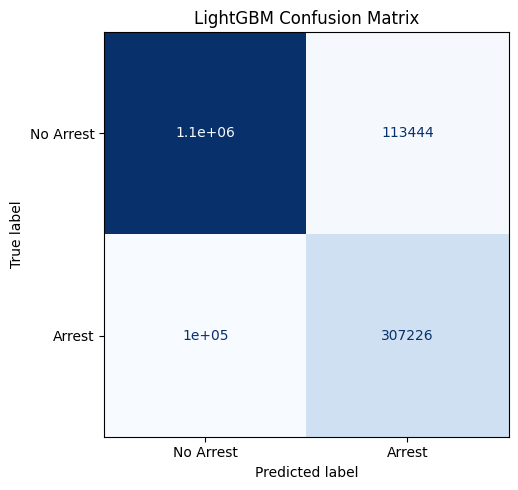

In [20]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    objective='binary',
    learning_rate=0.1,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

lgbm_results = evaluate_model(
    model=lgbm_model,
    model_name="LightGBM",
    X_train=X_train_over,
    y_train=y_train_over,
    X_test=X_test,
    y_test=y_test
)

# CatBoost


Training Time : 39.30 seconds
Accuracy  : 0.8623
Precision : 0.7317
Recall    : 0.7365
F1 Score  : 0.7341
ROC AUC   : 0.9057
PR AUC    : 0.8443
              precision    recall  f1-score   support

           0       0.91      0.91      0.91   1182771
           1       0.73      0.74      0.73    411361

    accuracy                           0.86   1594132
   macro avg       0.82      0.82      0.82   1594132
weighted avg       0.86      0.86      0.86   1594132



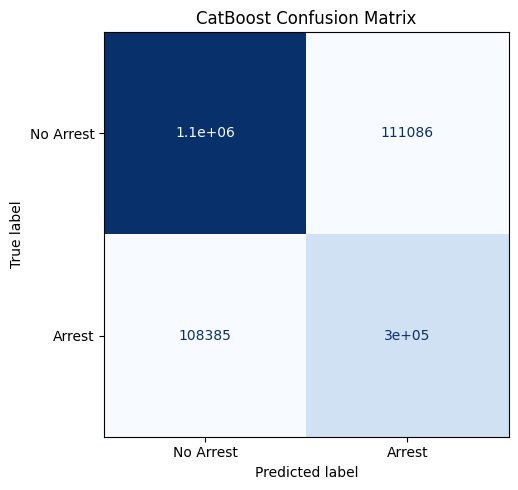

In [21]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    random_seed=42,
    verbose=0
)

cat_results = evaluate_model(
    model=cat_model,
    model_name="CatBoost",
    X_train=X_train_over,
    y_train=y_train_over,
    X_test=X_test,
    y_test=y_test
)

# Linear SVM


Training Time : 155.42 seconds
Accuracy  : 0.7477
Precision : 0.5089
Recall    : 0.6399
F1 Score  : 0.5669
ROC AUC   : 0.7540
PR AUC    : 0.5245
              precision    recall  f1-score   support

           0       0.86      0.79      0.82   1182771
           1       0.51      0.64      0.57    411361

    accuracy                           0.75   1594132
   macro avg       0.69      0.71      0.69   1594132
weighted avg       0.77      0.75      0.76   1594132



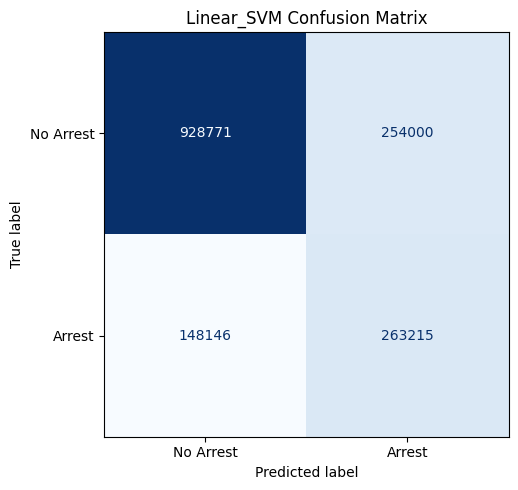

In [22]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm = LinearSVC(
    random_state=42,
    max_iter=5000   # as our dataset is large using standard SVM is not practical so sample 5000
)

# Calibrate to obtain probability estimates
svm_model = CalibratedClassifierCV(
    svm,
    method="sigmoid",
    cv=5
)

svm_results = evaluate_model(
    model=svm_model,
    model_name="Linear_SVM",
    X_train=X_train_scaled,
    y_train=y_train_over,
    X_test=X_test_scaled,
    y_test=y_test
)

# SGD Classifier (Linear SVM Loss = Hinge)


Training Time : 98.49 seconds
Accuracy  : 0.7416
Precision : 0.4994
Recall    : 0.6289
F1 Score  : 0.5567
ROC AUC   : 0.7387
PR AUC    : 0.4902
              precision    recall  f1-score   support

           0       0.86      0.78      0.82   1182771
           1       0.50      0.63      0.56    411361

    accuracy                           0.74   1594132
   macro avg       0.68      0.70      0.69   1594132
weighted avg       0.77      0.74      0.75   1594132



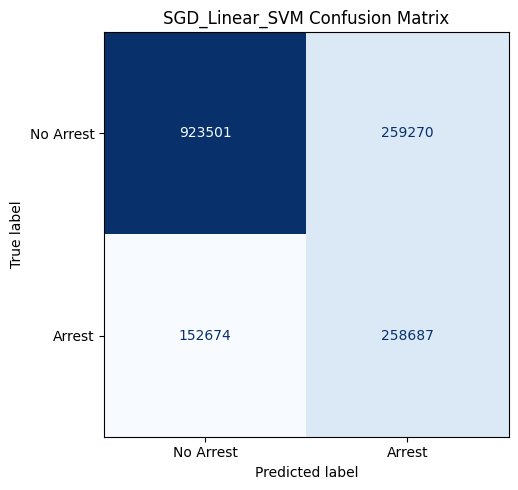

In [23]:
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV

# Base SGD Classifier
sgd = SGDClassifier(
    loss='hinge',
    penalty='l2',
    alpha=0.0001,
    max_iter=1000,
    tol=1e-3,
    random_state=42,
    n_jobs=-1
)

# Calibrate to obtain probability estimates
sgd_model = CalibratedClassifierCV(
    estimator=sgd,
    method='sigmoid',
    cv=5
)

sgd_results = evaluate_model(
    model=sgd_model,
    model_name="SGD_Linear_SVM",
    X_train=X_train_scaled,
    y_train=y_train_over,
    X_test=X_test_scaled,
    y_test=y_test
)

# MLP Classifier

Iteration 1, loss = 0.40425589
Validation score: 0.810796
Iteration 2, loss = 0.38839472
Validation score: 0.812851
Iteration 3, loss = 0.38599360
Validation score: 0.815417
Iteration 4, loss = 0.38455069
Validation score: 0.815901
Iteration 5, loss = 0.38360082
Validation score: 0.816474
Iteration 6, loss = 0.38300508
Validation score: 0.815080
Iteration 7, loss = 0.38247682
Validation score: 0.816253
Iteration 8, loss = 0.38214612
Validation score: 0.816469
Iteration 9, loss = 0.38182252
Validation score: 0.816426
Iteration 10, loss = 0.38153880
Validation score: 0.816464
Iteration 11, loss = 0.38131094
Validation score: 0.817810
Iteration 12, loss = 0.38112217
Validation score: 0.817327
Iteration 13, loss = 0.38091472
Validation score: 0.816779
Iteration 14, loss = 0.38078557
Validation score: 0.818252
Iteration 15, loss = 0.38071265
Validation score: 0.817595
Iteration 16, loss = 0.38054455
Validation score: 0.816983
Iteration 17, loss = 0.38043287
Validation score: 0.818394
Iterat

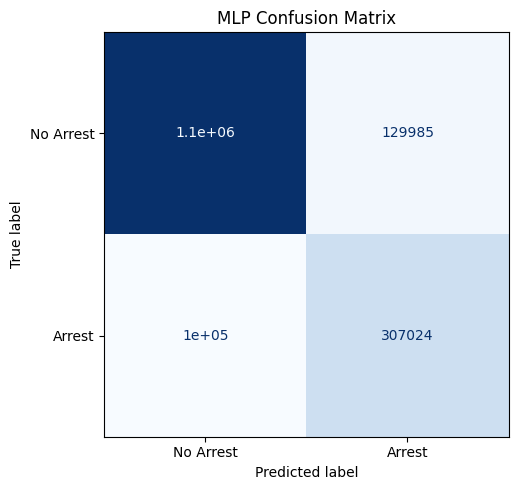

In [24]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    max_iter=100,
    shuffle=True,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=True
)

mlp_results = evaluate_model(
    model=mlp_model,
    model_name="MLP",
    X_train=X_train_scaled,         # Used scaled data
    y_train=y_train_over,
    X_test=X_test_scaled,
    y_test=y_test
)

# LSTM

In [25]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [26]:
# Reshape data for LSTM
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0],1,X_train_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0],1,X_test_scaled.shape[1])

print(X_train_lstm.shape)
print(X_test_lstm.shape)

(9462164, 1, 27)
(1594132, 1, 27)


In [27]:
# LSTM model

lstm_model = Sequential([

    LSTM(64,input_shape=(1, X_train_lstm.shape[2])),
    Dropout(0.3),
    Dense(32,activation='relu'),
    Dense(1,activation='sigmoid')

])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        23,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,665 (100.25 KB)

 Trainable params: 25,665 (100.25 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Train LSTM
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

start_time = time.time()

history = lstm_model.fit(
    X_train_lstm,
    y_train_over,
    validation_split=0.1,
    epochs=20,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining Time : {training_time:.2f} seconds")

Epoch 1/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.8119 - loss: 0.4075 - val_accuracy: 0.6701 - val_loss: 0.4955
Epoch 2/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8212 - loss: 0.3866 - val_accuracy: 0.6765 - val_loss: 0.5021
Epoch 3/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8227 - loss: 0.3824 - val_accuracy: 0.6795 - val_loss: 0.4941
Epoch 4/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8238 - loss: 0.3804 - val_accuracy: 0.6873 - val_loss: 0.4904
Epoch 5/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8245 - loss: 0.3788 - val_accuracy: 0.6816 - val_loss: 0.4873
Epoch 6/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8252 - loss: 0.3776 - val_accuracy: 0.6828 - val_loss: 0.5012
Epoch 7/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8260 - loss: 0.3766 - val_accuracy: 0.6816 - val_loss: 0.4889
Epoch 8/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8263 - loss: 0

In [29]:
# Deep Learning Model Evaluation Function

def evaluate_deep_learning_model(
    model,
    model_name,
    y_true,
    y_pred,
    y_prob,
    training_time,
    model_folder=MODEL_FOLDER,
    result_folder=RESULT_FOLDER
):
    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    print(f"\nTraining Time : {training_time:.2f} seconds")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")
    print(f"PR AUC    : {pr_auc:.4f}")

    # Classification Report
    report = classification_report(y_true,y_pred,output_dict=True)
    print(classification_report(y_true, y_pred))
    report_df = pd.DataFrame(report).transpose()
    report_path = os.path.join(result_folder,f"{model_name}_Classification_Report.csv")
    report_df.to_csv(report_path)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm,index=["Actual_0","Actual_1"],columns=["Predicted_0","Predicted_1"])
    cm_path = os.path.join(result_folder,f"{model_name}_Confusion_Matrix.csv")
    cm_df.to_csv(cm_path)

    # Plot
    fig, ax = plt.subplots(figsize=(6,5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Arrest","Arrest"])
    disp.plot(cmap="Blues",ax=ax,colorbar=False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    figure_path = os.path.join(result_folder,f"{model_name}_Confusion_Matrix.png")
    plt.savefig(figure_path,dpi=300,bbox_inches="tight")
    plt.show()

    # Save Model
    model_path = os.path.join(model_folder,f"{model_name}.keras")
    model.save(model_path)

    # Store Results
    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc,
        "Training Time (s)": round(training_time, 2)
    }
    all_results.append(results)

    return results

1557/1557 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Training Time : 401.20 seconds
Accuracy  : 0.8709
Precision : 0.7708
Recall    : 0.7110
F1 Score  : 0.7397
ROC AUC   : 0.9049
PR AUC    : 0.8441
              precision    recall  f1-score   support

           0       0.90      0.93      0.91   1182771
           1       0.77      0.71      0.74    411361

    accuracy                           0.87   1594132
   macro avg       0.84      0.82      0.83   1594132
weighted avg       0.87      0.87      0.87   1594132



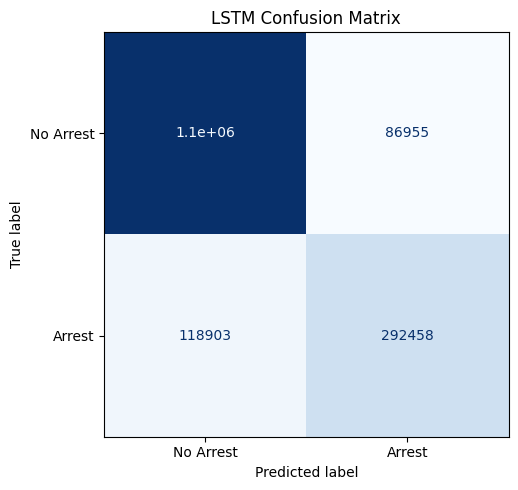

In [30]:
# Prediction

y_prob = lstm_model.predict( X_test_lstm,batch_size=1024)
y_prob = y_prob.ravel()
y_pred = (y_prob >= 0.5).astype(int)

lstm_results = evaluate_deep_learning_model(
    model=lstm_model,
    model_name="LSTM",
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    training_time=training_time
)

# GRU

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

gru_model = Sequential([
    GRU(units=64,input_shape=(1, X_train_lstm.shape[2])),
    Dropout(0.3),
    Dense(units=32,activation='relu'),
    Dense(units=1,activation='sigmoid')
])

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        17,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,969 (78.00 KB)

 Trainable params: 19,969 (78.00 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:

# Train GRU
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

start_time = time.time()
history = gru_model.fit(
    X_train_lstm,
    y_train_over,
    validation_split=0.1,
    epochs=20,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining Time : {training_time:.2f} seconds")

Epoch 1/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.8110 - loss: 0.4095 - val_accuracy: 0.6918 - val_loss: 0.4717
Epoch 2/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8212 - loss: 0.3872 - val_accuracy: 0.6828 - val_loss: 0.4891
Epoch 3/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8229 - loss: 0.3836 - val_accuracy: 0.6928 - val_loss: 0.4766
Epoch 4/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.8236 - loss: 0.3815 - val_accuracy: 0.6905 - val_loss: 0.4835

Training Time : 108.93 seconds


1557/1557 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Training Time : 108.93 seconds
Accuracy  : 0.8681
Precision : 0.7725
Recall    : 0.6929
F1 Score  : 0.7305
ROC AUC   : 0.8956
PR AUC    : 0.8303
              precision    recall  f1-score   support

           0       0.90      0.93      0.91   1182771
           1       0.77      0.69      0.73    411361

    accuracy                           0.87   1594132
   macro avg       0.83      0.81      0.82   1594132
weighted avg       0.86      0.87      0.87   1594132



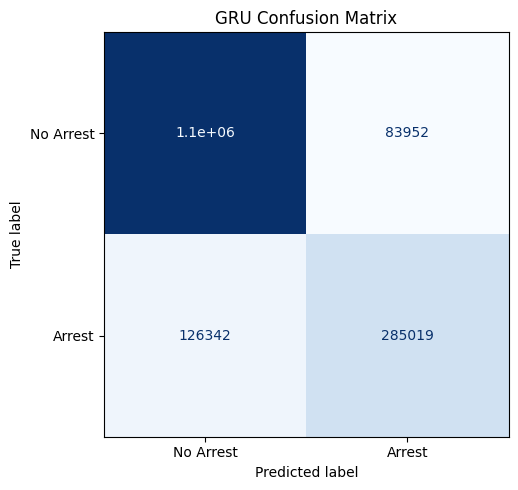

In [33]:
# Evaluate GRU

y_prob = gru_model.predict(X_test_lstm,batch_size=1024)
y_prob = y_prob.ravel()
y_pred = (y_prob >= 0.5).astype(int)

gru_results = evaluate_deep_learning_model(
    model=gru_model,
    model_name="GRU",
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    training_time=training_time
)

# TCN

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tcn import TCN

In [35]:
# Build TCN Model
tcn_model = Sequential([
    TCN(nb_filters=64,kernel_size=3, dilations=[1, 2, 4, 8],dropout_rate=0.3,input_shape=(1, X_train_lstm.shape[2])),
    Dense(32,activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
])

tcn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

tcn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn (TCN)                       │ (None, 64)             │        93,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,617 (373.50 KB)

 Trainable params: 95,617 (373.50 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Train TCN

early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

start_time = time.time()
history = tcn_model.fit(
    X_train_lstm,
    y_train_over,
    validation_split=0.1,
    epochs=20,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining Time : {training_time:.2f} seconds")

Epoch 1/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 230s 27ms/step - accuracy: 0.8140 - loss: 0.4045 - val_accuracy: 0.6787 - val_loss: 0.4648
Epoch 2/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 215s 26ms/step - accuracy: 0.8248 - loss: 0.3801 - val_accuracy: 0.6819 - val_loss: 0.4730
Epoch 3/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 213s 26ms/step - accuracy: 0.8267 - loss: 0.3767 - val_accuracy: 0.6851 - val_loss: 0.4713
Epoch 4/20
8317/8317 ━━━━━━━━━━━━━━━━━━━━ 208s 25ms/step - accuracy: 0.8277 - loss: 0.3746 - val_accuracy: 0.6830 - val_loss: 0.4797

Training Time : 865.74 seconds


1557/1557 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step

Training Time : 865.74 seconds
Accuracy  : 0.8752
Precision : 0.8063
Recall    : 0.6798
F1 Score  : 0.7376
ROC AUC   : 0.8999
PR AUC    : 0.8372
              precision    recall  f1-score   support

           0       0.89      0.94      0.92   1182771
           1       0.81      0.68      0.74    411361

    accuracy                           0.88   1594132
   macro avg       0.85      0.81      0.83   1594132
weighted avg       0.87      0.88      0.87   1594132



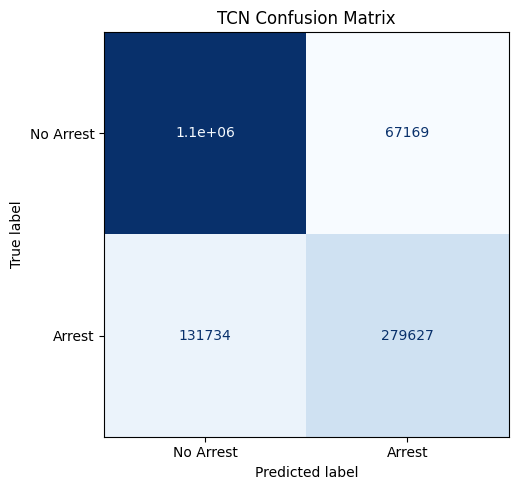

In [37]:
# Evaluate TCN
y_prob = tcn_model.predict(X_test_lstm,batch_size=1024)
y_prob = y_prob.ravel()
y_pred = (y_prob >= 0.5).astype(int)

tcn_results = evaluate_deep_learning_model(
    model=tcn_model,
    model_name="TCN",
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    training_time=training_time
)

In [ ]:
results_df = pd.DataFrame(all_results)
print("All Model Results")
print(results_df)

All Model Results
                  Model  Accuracy  Precision    Recall  F1 Score   ROC AUC  \
0   Logistic_Regression  0.747834   0.509058  0.640418  0.567232  0.754692   
1         Decision_Tree  0.834075   0.674767  0.689171  0.681893  0.786875   
2         Random_Forest  0.890843   0.872269  0.675973  0.761677  0.912209   
3           Extra_Trees  0.888956   0.896486  0.644040  0.749579  0.904412   
4     Gradient_Boosting  0.862718   0.742865  0.715741  0.729051  0.898634   
5              AdaBoost  0.829498   0.662413  0.691852  0.676812  0.875791   
6               XGBoost  0.863900   0.730498  0.748851  0.739560  0.911475   
7              LightGBM  0.863513   0.730325  0.746853  0.738497  0.910771   
8              CatBoost  0.862326   0.731717  0.736521  0.734111  0.905742   
9            Linear_SVM  0.747734   0.508908  0.639864  0.566922  0.753994   
10       SGD_Linear_SVM  0.741587   0.499437  0.628856  0.556724  0.738742   
11                  MLP  0.853010   0.702558  

In [ ]:
results_df.to_csv( r'2. Over_Sampling_Results\All_Model_Results.csv', index=False)


In [ ]:
# Sort by f1 score
results_df = results_df.sort_values(  by="F1 Score", ascending=False).reset_index(drop=True)
print(results_df)

                  Model  Accuracy  Precision    Recall  F1 Score   ROC AUC  \
0         Random_Forest  0.890843   0.872269  0.675973  0.761677  0.912209   
1           Extra_Trees  0.888956   0.896486  0.644040  0.749579  0.904412   
2                  LSTM  0.870865   0.770817  0.710952  0.739675  0.904886   
3               XGBoost  0.863900   0.730498  0.748851  0.739560  0.911475   
4              LightGBM  0.863513   0.730325  0.746853  0.738497  0.910771   
5                   TCN  0.875228   0.806316  0.679761  0.737649  0.899919   
6              CatBoost  0.862326   0.731717  0.736521  0.734111  0.905742   
7                   GRU  0.868082   0.772470  0.692868  0.730507  0.895552   
8     Gradient_Boosting  0.862718   0.742865  0.715741  0.729051  0.898634   
9                   MLP  0.853010   0.702558  0.746361  0.723797  0.902602   
10        Decision_Tree  0.834075   0.674767  0.689171  0.681893  0.786875   
11             AdaBoost  0.829498   0.662413  0.691852  0.676812

In [ ]:
results_df.to_csv(r'2. Over_Sampling_Results\All_Model_Results_Sorted.csv', index=False)

In [42]:
print("\nTop 5 Models Based on F1 Score\n")

print(
    results_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC AUC",
            "PR AUC"
        ]
    ].head()
)


Top 5 Models Based on F1 Score

           Model  Accuracy  Precision    Recall  F1 Score   ROC AUC    PR AUC
0  Random_Forest  0.890843   0.872269  0.675973  0.761677  0.912209  0.854487
1    Extra_Trees  0.888956   0.896486  0.644040  0.749579  0.904412  0.844405
2           LSTM  0.870865   0.770817  0.710952  0.739675  0.904886  0.844057
3        XGBoost  0.863900   0.730498  0.748851  0.739560  0.911475  0.852978
4       LightGBM  0.863513   0.730325  0.746853  0.738497  0.910771  0.852024


In [ ]:
results_df.insert( 0, "Rank", range(1, len(results_df) + 1))
print(results_df)

    Rank                Model  Accuracy  Precision    Recall  F1 Score  \
0      1        Random_Forest  0.890843   0.872269  0.675973  0.761677   
1      2          Extra_Trees  0.888956   0.896486  0.644040  0.749579   
2      3                 LSTM  0.870865   0.770817  0.710952  0.739675   
3      4              XGBoost  0.863900   0.730498  0.748851  0.739560   
4      5             LightGBM  0.863513   0.730325  0.746853  0.738497   
5      6                  TCN  0.875228   0.806316  0.679761  0.737649   
6      7             CatBoost  0.862326   0.731717  0.736521  0.734111   
7      8                  GRU  0.868082   0.772470  0.692868  0.730507   
8      9    Gradient_Boosting  0.862718   0.742865  0.715741  0.729051   
9     10                  MLP  0.853010   0.702558  0.746361  0.723797   
10    11        Decision_Tree  0.834075   0.674767  0.689171  0.681893   
11    12             AdaBoost  0.829498   0.662413  0.691852  0.676812   
12    13  Logistic_Regression  0.74783